# 08 Deep Learning — Evaluation & Comparison with Phase 1

---

## Purpose

Evaluate the trained DL models on the **same 20 % hold-out test set** used in
Phase 1, then build a comprehensive comparison across all models.

### Models Evaluated
1. **BiLSTM + Attention (Random Init)** — trainable embedding from scratch
2. **BiLSTM + GloVe** — embedding layer initialised with GloVe 6B 100d
3. **DistilBERT** (optional) — fine-tuned Transformer encoder

### Outputs
- Confusion matrices and ROC curves
- Classification reports
- **Phase 1 (ML) vs Phase 2 (DL)** comparison table and bar chart
- Error analysis: accuracy by text length, confidence distributions
- Saved metrics (JSON/CSV)

### Prerequisites
Run `06_dl_data_preprocessing.ipynb` → `07_dl_model_training.ipynb` → `scripts/retrain_lstm_with_glove.py` first.

## 1. Imports and Load Artifacts

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, auc,
)
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

PROJECT_ROOT = Path('.').resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.deep_learning import (
    LSTMConfig, TransformerConfig,
    TextClassificationDataset, TransformerDataset,
    BiLSTMClassifier, DistilBERTClassifier,
    evaluate_lstm, evaluate_transformer,
    get_device,
)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 5)

RESULTS_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
METRICS_DIR = PROJECT_ROOT / 'metrics'
for d in [RESULTS_DIR, FIGURES_DIR, METRICS_DIR]:
    d.mkdir(exist_ok=True)

device = get_device()
print(f'PyTorch {torch.__version__} | Device: {device}')

PyTorch 2.11.0 | Device: mps


In [2]:
# Load test data
test_ids = torch.load(RESULTS_DIR / 'dl_test_ids.pt', weights_only=True)
y_test   = np.load(RESULTS_DIR / 'dl_y_test.npy')

bert_test_enc = torch.load(RESULTS_DIR / 'dl_bert_test.pt', weights_only=False)

X_test_text = np.load(RESULTS_DIR / 'dl_test_texts.npy', allow_pickle=True)

with open(RESULTS_DIR / 'dl_tokenizer.json') as f:
    tok_data = json.load(f)
vocab_size = len(tok_data['word2idx'])

print(f'Test set: {len(y_test):,} samples')
print(f'Word-level tensor: {test_ids.shape}')
print(f'BERT tensor: {bert_test_enc["input_ids"].shape}')

/Users/bhavanishanker/predictive-sales-analytics-engine/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test set: 20,000 samples
Word-level tensor: torch.Size([20000, 475])
BERT tensor: torch.Size([20000, 512])


## 2. Load Trained Models

We load **two** BiLSTM variants for comparison:
1. **Original** (random init, `embed_dim=128`)
2. **GloVe** (pretrained GloVe 6B 100d, `embed_dim=100`)

In [3]:
# ── BiLSTM (Random Init) ─────────────────────────────────────────
original_model_path = RESULTS_DIR / 'model_lstm_best.pt'
has_original = original_model_path.exists()

if has_original:
    original_cfg = LSTMConfig(
        vocab_size=vocab_size,
        embed_dim=128,
        hidden_dim=128,
        num_layers=1,
        dropout=0.5,
        bidirectional=True,
        num_classes=1,
        use_attention=True,
    )
    original_model = BiLSTMClassifier(original_cfg, pad_idx=0)
    original_model.load_state_dict(torch.load(original_model_path, weights_only=True))
    original_model = original_model.to(device)
    original_model.eval()
    print(f'BiLSTM (Random Init) loaded ({sum(p.numel() for p in original_model.parameters()):,} params)')
else:
    original_model = None
    print('⚠ model_lstm_best.pt not found — skipping BiLSTM (Random Init)')

# ── BiLSTM + GloVe ───────────────────────────────────────────────
glove_model_path = RESULTS_DIR / 'model_lstm_glove_best.pt'
has_glove = glove_model_path.exists()

if has_glove:
    glove_cfg = LSTMConfig(
        vocab_size=vocab_size,
        embed_dim=100,         # GloVe 6B 100d
        hidden_dim=128,
        num_layers=1,
        dropout=0.5,
        bidirectional=True,
        num_classes=1,
        use_attention=True,
    )
    glove_model = BiLSTMClassifier(glove_cfg, pad_idx=0)
    glove_model.load_state_dict(torch.load(glove_model_path, weights_only=True))
    glove_model = glove_model.to(device)
    glove_model.eval()
    print(f'BiLSTM + GloVe loaded ({sum(p.numel() for p in glove_model.parameters()):,} params)')
else:
    glove_model = None
    print('⚠ model_lstm_glove_best.pt not found — skipping BiLSTM + GloVe')

# ── DistilBERT (optional) ────────────────────────────────────────
distilbert_model_path = RESULTS_DIR / 'model_distilbert_best.pt'
has_distilbert = False  # Set True to enable DistilBERT evaluation
has_bert = has_distilbert

if has_distilbert:
    bert_cfg = TransformerConfig(
        model_name='distilbert-base-uncased', max_length=512,
        dropout=0.3, num_classes=2, freeze_layers=2,
    )
    bert_model = DistilBERTClassifier(bert_cfg)
    bert_model.load_state_dict(torch.load(distilbert_model_path, weights_only=False))
    bert_model = bert_model.to(device)
    bert_model.eval()
    print(f'DistilBERT loaded ({sum(p.numel() for p in bert_model.parameters()):,} params)')
else:
    print('DistilBERT flagged to skip.')
    bert_model = None

BiLSTM (Random Init) loaded (3,997,569 params)
BiLSTM + GloVe loaded (3,159,613 params)
DistilBERT flagged to skip.


In [4]:
# Create test DataLoaders
test_dataset = TextClassificationDataset(test_ids, y_test)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

bert_test_ds = TransformerDataset(bert_test_enc, y_test)
bert_test_loader = DataLoader(bert_test_ds, batch_size=16, shuffle=False, num_workers=0)

print(f'Test loaders: LSTM={len(test_loader)} batches, BERT={len(bert_test_loader)} batches')

Test loaders: LSTM=313 batches, BERT=1250 batches


## 3. Generate Predictions

### Helper function

In [5]:
def evaluate_bilstm(model, loader, y_true, device, model_name):
    """Evaluate a BiLSTM model. Returns (metrics_dict, preds, probs)."""
    model.eval()
    is_binary = model.config.num_classes == 1
    all_preds, all_probs = [], []

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            logits, _ = model(batch_x)
            if is_binary:
                logits = logits.squeeze(-1)
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).long()
            else:
                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = logits.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    metrics = {
        'Accuracy':  accuracy_score(y_true, all_preds),
        'Precision': precision_score(y_true, all_preds, zero_division=0),
        'Recall':    recall_score(y_true, all_preds, zero_division=0),
        'F1':        f1_score(y_true, all_preds, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, all_probs),
        'AP':        average_precision_score(y_true, all_probs),
    }

    print(f'{model_name} — Test Metrics')
    for k, v in metrics.items():
        print(f'  {k:12s}: {v:.4f}')

    return metrics, all_preds, all_probs

### 3a. BiLSTM (Random Init)

In [6]:
# BiLSTM (Random Init) evaluation
if has_original:
    original_metrics, original_preds, original_probs = evaluate_bilstm(
        original_model, test_loader, y_test, device, 'BiLSTM + Attention (Random Init)'
    )
else:
    print('BiLSTM (Random Init) not available. Skipping.')

BiLSTM + Attention (Random Init) — Test Metrics
  Accuracy    : 0.8277
  Precision   : 0.8060
  Recall      : 0.8626
  F1          : 0.8333
  ROC-AUC     : 0.9102
  AP          : 0.9066


### 3b. BiLSTM + GloVe

In [7]:
# BiLSTM + GloVe evaluation
if has_glove:
    glove_metrics, glove_preds, glove_probs = evaluate_bilstm(
        glove_model, test_loader, y_test, device, 'BiLSTM + GloVe'
    )
else:
    print('BiLSTM + GloVe not available. Skipping.')

BiLSTM + GloVe — Test Metrics
  Accuracy    : 0.8389
  Precision   : 0.8153
  Recall      : 0.8757
  F1          : 0.8444
  ROC-AUC     : 0.9229
  AP          : 0.9208


### 3c. DistilBERT (if available)

In [8]:
# DistilBERT evaluation
criterion = nn.CrossEntropyLoss()

if has_distilbert:
    bert_test_loss, bert_test_acc, bert_preds, bert_probs = evaluate_transformer(
        bert_model, bert_test_loader, criterion, device,
    )

    bert_metrics = {
        'Accuracy':  accuracy_score(y_test, bert_preds),
        'Precision': precision_score(y_test, bert_preds),
        'Recall':    recall_score(y_test, bert_preds),
        'F1':        f1_score(y_test, bert_preds),
        'ROC-AUC':   roc_auc_score(y_test, bert_probs),
        'AP':        average_precision_score(y_test, bert_probs),
    }

    print('DistilBERT — Test Metrics')
    for k, v in bert_metrics.items():
        print(f'  {k:12s}: {v:.4f}')
else:
    print('DistilBERT Not available. Skipping eval')

DistilBERT Not available. Skipping eval


## 4. Confusion Matrices

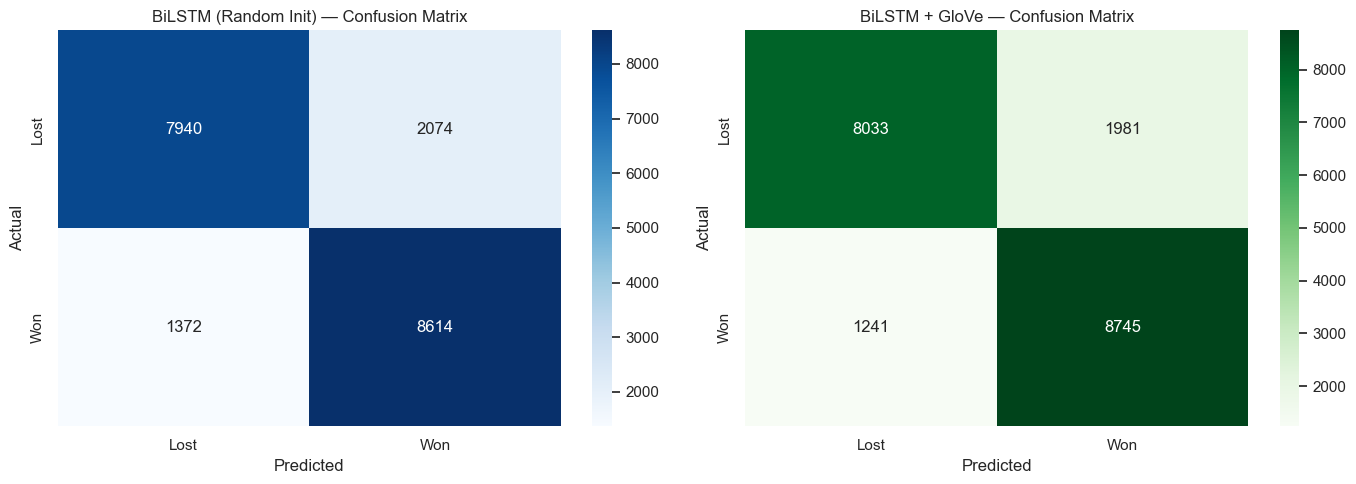

Saved: figures/dl_confusion_matrices.png


In [9]:
class_names = ['Lost', 'Won']

# Count how many models we have
n_models = sum([has_original, has_glove, has_distilbert])
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
if n_models == 1:
    axes = [axes]

plot_data = []
if has_original:
    plot_data.append((original_preds, 'BiLSTM (Random Init)', 'Blues'))
if has_glove:
    plot_data.append((glove_preds, 'BiLSTM + GloVe', 'Greens'))
if has_distilbert:
    plot_data.append((bert_preds, 'DistilBERT', 'Oranges'))

for i, (preds, title, cmap) in enumerate(plot_data):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names, ax=axes[i])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'{title} — Confusion Matrix')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_confusion_matrices.png')

## 5. Classification Reports

In [10]:
if has_original:
    print('=' * 60)
    print('BiLSTM (Random Init) — Classification Report')
    print('=' * 60)
    print(classification_report(y_test, original_preds, target_names=class_names))

if has_glove:
    print('=' * 60)
    print('BiLSTM + GloVe — Classification Report')
    print('=' * 60)
    print(classification_report(y_test, glove_preds, target_names=class_names))

if has_distilbert:
    print('=' * 60)
    print('DistilBERT — Classification Report')
    print('=' * 60)
    print(classification_report(y_test, bert_preds, target_names=class_names))

BiLSTM (Random Init) — Classification Report
              precision    recall  f1-score   support

        Lost       0.85      0.79      0.82     10014
         Won       0.81      0.86      0.83      9986

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000

BiLSTM + GloVe — Classification Report
              precision    recall  f1-score   support

        Lost       0.87      0.80      0.83     10014
         Won       0.82      0.88      0.84      9986

    accuracy                           0.84     20000
   macro avg       0.84      0.84      0.84     20000
weighted avg       0.84      0.84      0.84     20000



## 6. ROC Curves

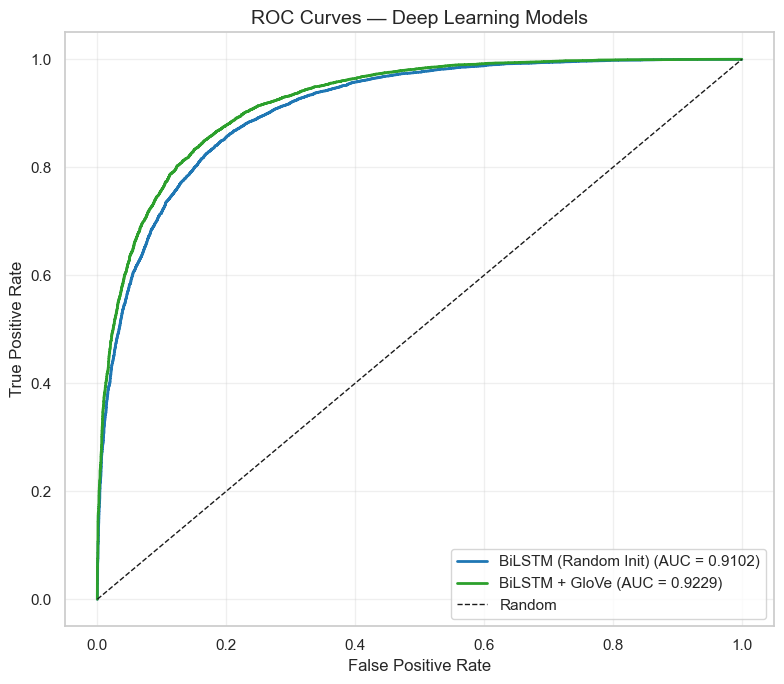

Saved: figures/dl_roc_curves.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_data = []
if has_original:
    roc_data.append((original_probs, 'BiLSTM (Random Init)', '#1f77b4'))
if has_glove:
    roc_data.append((glove_probs, 'BiLSTM + GloVe', '#2ca02c'))
if has_distilbert:
    roc_data.append((bert_probs, 'DistilBERT', '#ff7f0e'))

for probs, name, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Deep Learning Models', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_roc_curves.png')

## 7. GloVe Improvement over Random Init

In [12]:
if has_original and has_glove:
    print('GloVe Init Improvement over Random Init:')
    print(f"  {'Metric':<12} {'Random Init':>12} {'GloVe Init':>12} {'Δ':>10}")
    print(f"  {'-' * 48}")
    for k in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'AP']:
        orig_v = original_metrics[k]
        glove_v = glove_metrics[k]
        delta = glove_v - orig_v
        arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
        print(f"  {k:<12} {orig_v:>12.4f} {glove_v:>12.4f} {delta:>+9.4f} {arrow}")
else:
    print('Need both models to compare. Skipping.')

GloVe Init Improvement over Random Init:
  Metric        Random Init   GloVe Init          Δ
  ------------------------------------------------
  Accuracy           0.8277       0.8389   +0.0112 ↑
  Precision          0.8060       0.8153   +0.0094 ↑
  Recall             0.8626       0.8757   +0.0131 ↑
  F1                 0.8333       0.8444   +0.0111 ↑
  ROC-AUC            0.9102       0.9229   +0.0127 ↑
  AP                 0.9066       0.9208   +0.0142 ↑


## 8. Full Model Comparison — Phase 1 (ML) vs Phase 2 (DL)

In [13]:
# Phase 1 ML results (from metrics/evaluation_metrics.json)
phase1_metrics = {
    'Logistic Regression (ML)': {
        'Accuracy': 0.9634, 'Precision': 0.9504, 'Recall': 0.9777,
        'F1': 0.9639, 'ROC-AUC': 0.9957, 'AP': 0.9957,
    },
    'Random Forest (ML)': {
        'Accuracy': 0.9594, 'Precision': 0.9453, 'Recall': 0.9751,
        'F1': 0.9600, 'ROC-AUC': 0.9951, 'AP': 0.9951,
    },
}

all_results = {**phase1_metrics}
if has_original:
    all_results['BiLSTM + Attention (DL)'] = original_metrics
if has_glove:
    all_results['BiLSTM + GloVe (DL)'] = glove_metrics
if has_distilbert:
    all_results['DistilBERT (DL)'] = bert_metrics

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'AP']]

print('\n' + '='*80)
print('FULL MODEL COMPARISON — Phase 1 (ML) vs Phase 2 (DL)')
print('='*80)
display(comparison_df.round(4).style.highlight_max(axis=0, color='lightgreen'))


FULL MODEL COMPARISON — Phase 1 (ML) vs Phase 2 (DL)


,Accuracy,Precision,Recall,F1,ROC-AUC,AP
Logistic Regression (ML),0.963400,0.950400,0.977700,0.963900,0.995700,0.995700
Random Forest (ML),0.959400,0.945300,0.975100,0.960000,0.995100,0.995100
BiLSTM + Attention (DL),0.827700,0.806000,0.862600,0.833300,0.910200,0.906600
BiLSTM + GloVe (DL),0.838900,0.815300,0.875700,0.844400,0.922900,0.920800


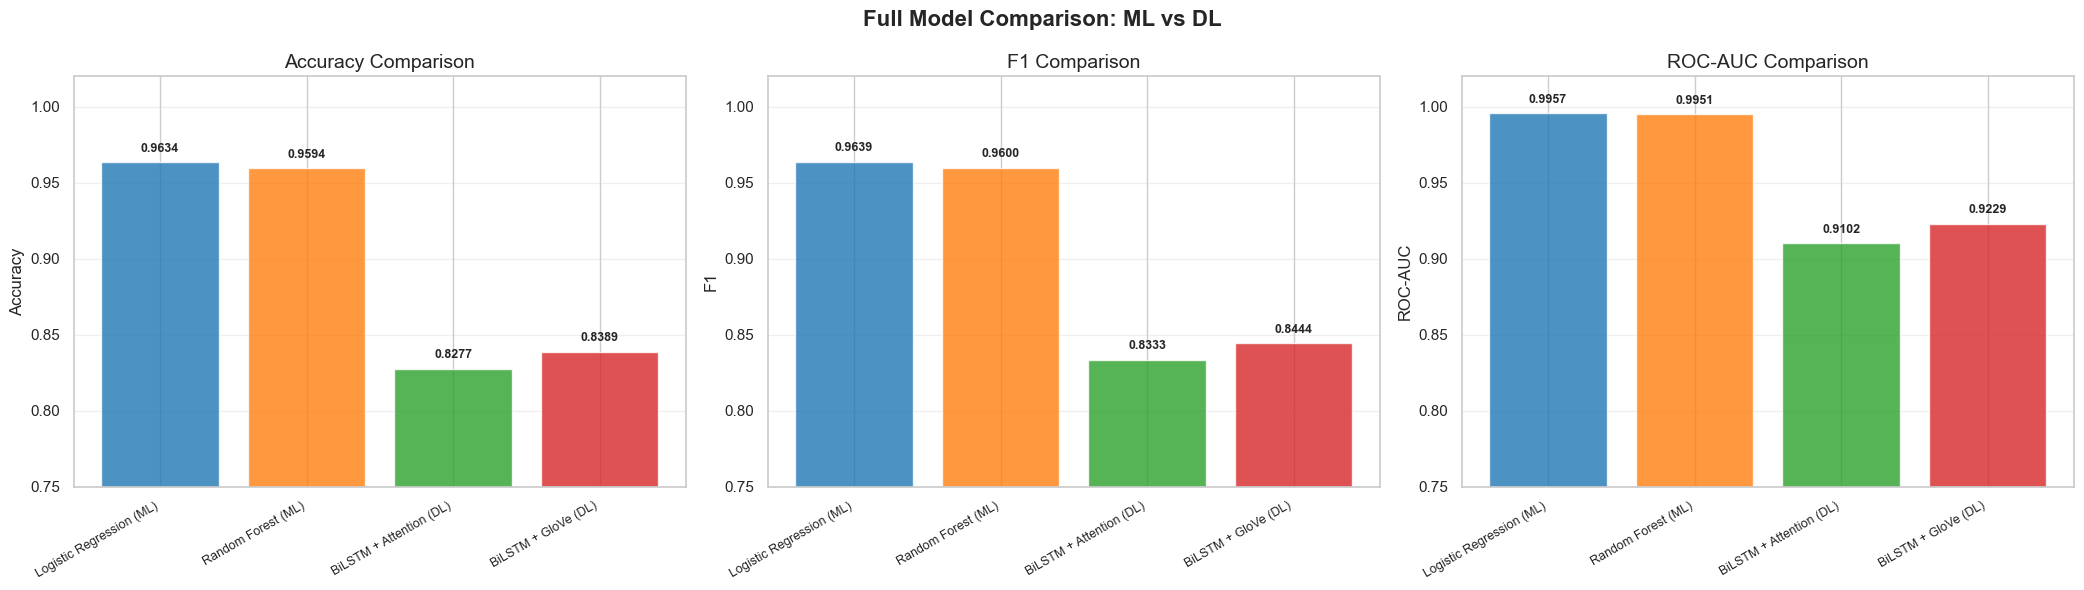

Saved: figures/ml_vs_dl_comparison.png


In [14]:
# Comparison bar chart
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']
n_metrics = len(metrics_to_plot)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(1, n_metrics, figsize=(7 * n_metrics, 6))

for ax, metric in zip(axes, metrics_to_plot):
    vals = comparison_df[metric]
    bars = ax.bar(range(len(vals)), vals, color=colors[:len(vals)], alpha=0.8)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} Comparison', fontsize=14)
    ax.set_ylim(0.75, 1.02)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Full Model Comparison: ML vs DL', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ml_vs_dl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/ml_vs_dl_comparison.png')

## 9. Error Analysis

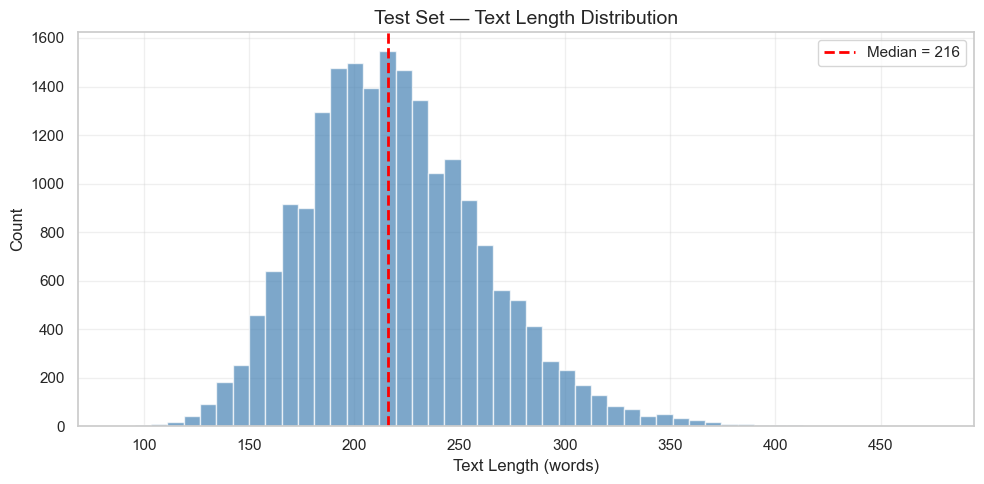

Saved: figures/dl_text_length_distribution.png


In [ ]:
# Text-length distribution
text_lengths = np.array([len(str(t).split()) for t in X_test_text])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(text_lengths, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.set_xlabel('Text Length (words)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Test Set — Text Length Distribution', fontsize=14)
ax.axvline(np.median(text_lengths), color='red', lw=2, ls='--',
           label=f'Median = {np.median(text_lengths):.0f}')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_text_length_distribution.png')

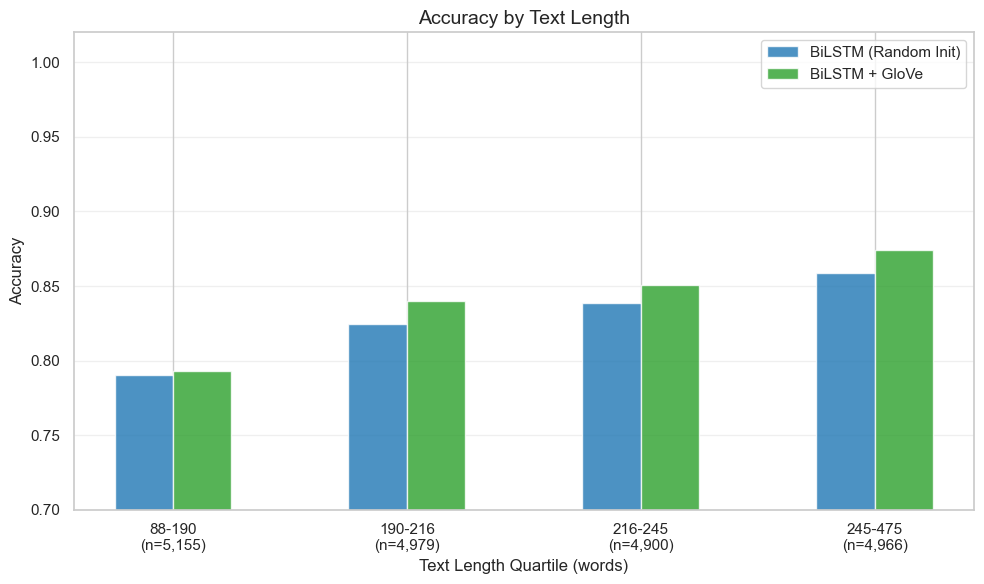

Saved: figures/dl_accuracy_by_length.png


In [ ]:
# Accuracy by text length
bins = np.percentile(text_lengths, [0, 25, 50, 75, 100])
bin_labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
bin_indices = np.digitize(text_lengths, bins[1:], right=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(bin_labels))
width = 0.25
offset = 0

acc_data = []
if has_original:
    acc_data.append((original_preds, 'BiLSTM (Random Init)', '#1f77b4'))
if has_glove:
    acc_data.append((glove_preds, 'BiLSTM + GloVe', '#2ca02c'))
if has_distilbert:
    acc_data.append((bert_preds, 'DistilBERT', '#ff7f0e'))

counts = []
for i in range(len(bin_labels)):
    mask = bin_indices == i
    counts.append(mask.sum())

for preds, name, color in acc_data:
    accs = []
    for i in range(len(bin_labels)):
        mask = bin_indices == i
        if mask.sum() > 0:
            accs.append(accuracy_score(y_test[mask], preds[mask]))
        else:
            accs.append(0)
    ax.bar(x + offset, accs, width, label=name, color=color, alpha=0.8)
    offset += width

ax.set_xlabel('Text Length Quartile (words)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Accuracy by Text Length', fontsize=14)
ax.set_xticks(x + width * (len(acc_data) - 1) / 2)
ax.set_xticklabels([f'{l}\n(n={c:,})' for l, c in zip(bin_labels, counts)])
ax.legend()
ax.set_ylim(0.7, 1.02)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_accuracy_by_length.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_accuracy_by_length.png')

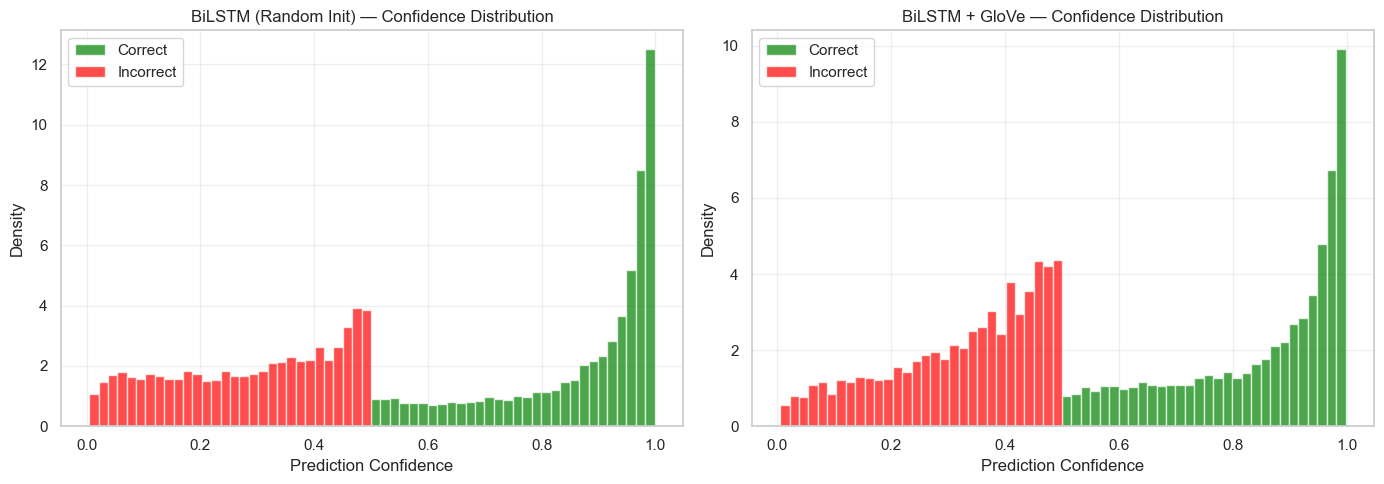

Saved: figures/dl_confidence_distribution.png


In [ ]:
# Confidence distributions for correct vs incorrect predictions
n_conf = sum([has_original, has_glove, has_distilbert])
fig, axes = plt.subplots(1, n_conf, figsize=(7 * n_conf, 5))
if n_conf == 1:
    axes = [axes]

conf_data = []
if has_original:
    original_correct = (original_preds == y_test)
    conf_data.append((original_probs, original_correct, 'BiLSTM (Random Init)'))
if has_glove:
    glove_correct = (glove_preds == y_test)
    conf_data.append((glove_probs, glove_correct, 'BiLSTM + GloVe'))
if has_distilbert:
    bert_correct = (bert_preds == y_test)
    conf_data.append((bert_probs, bert_correct, 'DistilBERT'))

for i, (probs, correct, title) in enumerate(conf_data):
    confidence = np.where(y_test == 1, probs, 1 - probs)
    axes[i].hist(confidence[correct],  bins=30, alpha=0.7, label='Correct',   color='green', density=True)
    axes[i].hist(confidence[~correct], bins=30, alpha=0.7, label='Incorrect', color='red',   density=True)
    axes[i].set_xlabel('Prediction Confidence')
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{title} — Confidence Distribution')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dl_confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/dl_confidence_distribution.png')

## 10. Save All Metrics

In [ ]:
# DL metrics
dl_metrics = {}
dl_reports = {}
dl_cm = {}

if has_original:
    dl_metrics['BiLSTM + Attention'] = original_metrics
    dl_reports['BiLSTM + Attention'] = classification_report(y_test, original_preds, target_names=class_names, output_dict=True)
    dl_cm['BiLSTM + Attention'] = confusion_matrix(y_test, original_preds).tolist()

if has_glove:
    dl_metrics['BiLSTM + GloVe'] = glove_metrics
    dl_reports['BiLSTM + GloVe'] = classification_report(y_test, glove_preds, target_names=class_names, output_dict=True)
    dl_cm['BiLSTM + GloVe'] = confusion_matrix(y_test, glove_preds).tolist()

if has_distilbert:
    dl_metrics['DistilBERT'] = bert_metrics
    dl_reports['DistilBERT'] = classification_report(y_test, bert_preds, target_names=class_names, output_dict=True)
    dl_cm['DistilBERT'] = confusion_matrix(y_test, bert_preds).tolist()

with open(METRICS_DIR / 'dl_evaluation_metrics.json', 'w') as f:
    json.dump(dl_metrics, f, indent=2)

pd.DataFrame(dl_metrics).T.to_csv(METRICS_DIR / 'dl_evaluation_metrics.csv')

# Full ML vs DL comparison
comparison_df.to_csv(METRICS_DIR / 'ml_vs_dl_comparison.csv')
comparison_df.to_json(METRICS_DIR / 'ml_vs_dl_comparison.json')

with open(METRICS_DIR / 'dl_classification_reports.json', 'w') as f:
    json.dump(dl_reports, f, indent=2)

with open(METRICS_DIR / 'dl_confusion_matrices.json', 'w') as f:
    json.dump(dl_cm, f, indent=2)

print('Metrics saved to metrics/')
print('  dl_evaluation_metrics.json / .csv')
print('  ml_vs_dl_comparison.json / .csv')
print('  dl_classification_reports.json')
print('  dl_confusion_matrices.json')

Metrics saved to metrics/
  dl_evaluation_metrics.json / .csv
  ml_vs_dl_comparison.json / .csv
  dl_classification_reports.json
  dl_confusion_matrices.json


## 11. Summary

In [19]:
best_ml_f1 = 0.9639  # Phase 1 Logistic Regression

# Build DL results table rows
dl_rows = []
dl_f1_values = {}

if has_original:
    dl_rows.append(f"| BiLSTM + Attention (DL) | {original_metrics['F1']:.4f} | {original_metrics['ROC-AUC']:.4f} | {original_metrics['Accuracy']:.4f} |")
    dl_f1_values['BiLSTM + Attention'] = original_metrics['F1']

if has_glove:
    dl_rows.append(f"| BiLSTM + GloVe (DL) | {glove_metrics['F1']:.4f} | {glove_metrics['ROC-AUC']:.4f} | {glove_metrics['Accuracy']:.4f} |")
    dl_f1_values['BiLSTM + GloVe'] = glove_metrics['F1']

if has_distilbert:
    dl_rows.append(f"| DistilBERT (DL) | {bert_metrics['F1']:.4f} | {bert_metrics['ROC-AUC']:.4f} | {bert_metrics['Accuracy']:.4f} |")
    dl_f1_values['DistilBERT'] = bert_metrics['F1']

dl_rows_str = '\n'.join(dl_rows)

best_dl_name = max(dl_f1_values, key=dl_f1_values.get) if dl_f1_values else 'N/A'
best_dl_f1 = max(dl_f1_values.values()) if dl_f1_values else 0

# GloVe improvement note
glove_note = ''
if has_original and has_glove:
    delta = glove_metrics['F1'] - original_metrics['F1']
    glove_note = f'- **GloVe improvement over Random Init**: F1 +{delta:.4f}'

summary = f"""
## Phase 2 Deep Learning — Evaluation Summary

### Test Set Results

| Model | F1 | ROC-AUC | Accuracy |
|-------|----|---------|--------|
| Logistic Regression (ML) | 0.9639 | 0.9957 | 0.9634 |
| Random Forest (ML) | 0.9600 | 0.9951 | 0.9594 |
{dl_rows_str}

### Key Findings

- **Best DL model**: {best_dl_name} (F1 = {best_dl_f1:.4f})
- **Best ML model**: Logistic Regression (F1 = {best_ml_f1:.4f})
{glove_note}
- ML baseline remains competitive — DL processes raw text without hand-crafted features

### What DL brings that ML cannot

1. **End-to-end learning**: No manual feature engineering needed
2. **Attention interpretability**: Attention weights highlight predictive conversation segments
3. **Transfer learning** (GloVe / DistilBERT): Leverages pretraining on massive corpora

### Next → Phase 3 (Hybrid)

Combine ML tabular features with DL text representations in a fusion model.
"""
display(Markdown(summary))


## Phase 2 Deep Learning — Evaluation Summary

### Test Set Results

| Model | F1 | ROC-AUC | Accuracy |
|-------|----|---------|--------|
| Logistic Regression (ML) | 0.9639 | 0.9957 | 0.9634 |
| Random Forest (ML) | 0.9600 | 0.9951 | 0.9594 |
| BiLSTM + Attention (DL) | 0.8333 | 0.9102 | 0.8277 |
| BiLSTM + GloVe (DL) | 0.8444 | 0.9229 | 0.8389 |

### Key Findings

- **Best DL model**: BiLSTM + GloVe (F1 = 0.8444)
- **Best ML model**: Logistic Regression (F1 = 0.9639)
- **GloVe improvement over Random Init**: F1 +0.0111
- ML baseline remains competitive — DL processes raw text without hand-crafted features

### What DL brings that ML cannot

1. **End-to-end learning**: No manual feature engineering needed
2. **Attention interpretability**: Attention weights highlight predictive conversation segments
3. **Transfer learning** (GloVe / DistilBERT): Leverages pretraining on massive corpora

### Next → Phase 3 (Hybrid)

Combine ML tabular features with DL text representations in a fusion model.
